# Segmentación basada en color

Este proceso permite separar la imagen en regiones utilizando informacion del color.
En este ejercicio usted debe implementar la segmentacion de imagenes para los mod-
elos de color RGB y HSV. En cada caso debera determinar el subespacio a segmentar
para generar una mascara, que luego utilizara para extraer s ́olo la informaci ́on de
inter ́es de la imagen original.

En cuanto a la metodolog ́ıa, le proponemos que utilice la imagen ‘futbol.jpg’ y
defina una ROI representativa del color a segmentar, luego
- para el modelo RGB:use la informaci ́on para calcular el centro de la esfera y su radio. Podr ́ıa reem-
plazar la f ́ormula de la esfera por la de una elipsoide.
- para el modelo HSV:Utilice las componentes H y S para determinar el subespacio rectangular a seg-
mentar.

Consejo: utilizar los histogramas puede ser una buena alternativa.
- Compare, analice y saque conclusiones sobre los resultados de ambos m ́etodos.
- Pruebe su implementaci ́on con otras im ́agenes, por ejemplo segmentando s ́olo la
piel en las im ́agenes s01i08HCM.png, s03i10HDM.png, s05i08HLB.png,
s06i13HLV.png, s08i06HMA.png.
Analice el desempe ̃no de ambos m ́etodos.
¿Qu ́e m ́etodo le parece mejor?
¿Es posible obtener un conjunto de valores  ́optimo para todas las im ́agenes?
¿Es suficiente aplicar la segmentaci ́on sin m ́etodos de pre-procesamiento (realce
o filtrado)?
¿D ́onde cree usted que est ́an los mayores inconvenientes?
¿Qu ́e condiciones observa en la escena que son homog ́eneas y cu ́ales heterog ́eneas?
(distancia c ́amara-objeto, foco, iluminaci ́on ambiente, fondo de la escena, ubi-
caci ́on y pose del sujeto, color de piel, vestimenta y accesorios, etc.)
A partir de estos an ́alisis, ¿Podr ́ıa usted generar una lista de consideraciones
 ́utiles para generar una base de datos de im ́agenes?
3


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

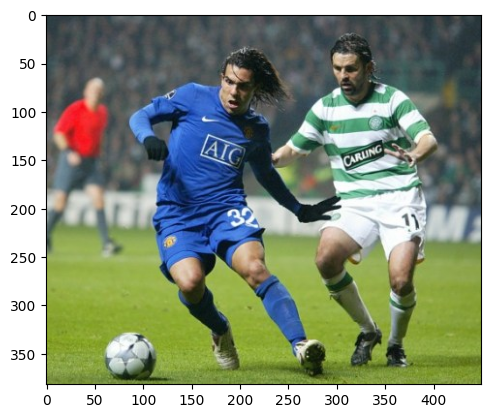

In [2]:

carlitosss = cv2.imread("../Imagenes_cursado/futbol.jpg")

img_rgb = cv2.cvtColor(carlitosss, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()


# Analisis RGB

Tenemos que definir una región dentro del hipercubo para el rango de colores de la region. Nos sería de interes extraer el uniforme del poderoso manchester united

32.888 66.7324 136.9636


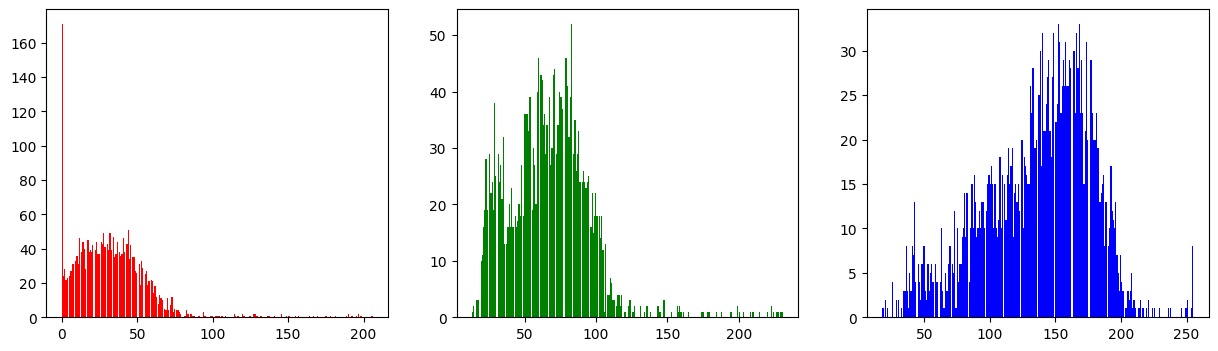

In [3]:
r, g, b= cv2.split(img_rgb)

#aproximadamente voy a seleccionar una region de la camiseta y analizar la distribucion de los colores en esa region [150:150, 150:150]

fig, axs = plt.subplots(1, 3, figsize=(15,4))
axs[0].hist(np.ravel(r[150:200, 150:200]), bins = 255, color = 'red')
axs[1].hist(np.ravel(g[150:200, 150:200]), bins = 255, color = 'green')
axs[2].hist(np.ravel(b[150:200, 150:200]), bins = 255, color = 'blue')

#el centro de mi esfera va a ser el centro de estos puntos

c_r = np.mean(np.ravel(r[150:200, 150:200]))
c_g = np.mean(np.ravel(g[150:200, 150:200]))
c_b= np.mean(np.ravel(b[150:200, 150:200]))

r_std = np.std(np.ravel(r[150:200, 150:200]))
g_std = np.std(np.ravel(g[150:200, 150:200]))
b_std= np.std(np.ravel(b[150:200, 150:200]))

desvio_prom = (r_std + g_std +b_std)/3 #porque el desvio del azul es muy grande!
print(c_r, c_g, c_b)
#para el radio vamos a elegir la desviación promedio de todas las dimension


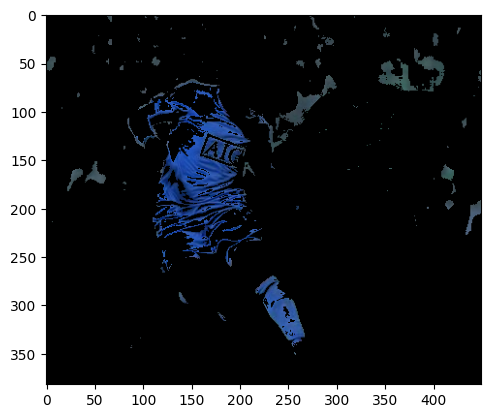

In [4]:
def sphere (point):
    if ((point[0]-c_r)**2 + (point[1]-c_g)**2 + (point[2]-c_b)**2)<(2*desvio_prom)**2:
        return True
    return False

#recorremos todas las matrices

roi_r = np.zeros_like(r)
roi_g = np.zeros_like(r)
roi_b = np.zeros_like(r)

for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        point = np.array([
            r[i,j],
            g[i,j],
            b[i,j]]
        )
        if sphere(point) == True:
            roi_r[i,j] = r[i,j]
            roi_g[i,j] = g[i,j]
            roi_b[i,j] = b[i,j]

roi_rgb = cv2.merge([roi_r, roi_g, roi_b])
plt.imshow(roi_rgb)
plt.show()




# HSV

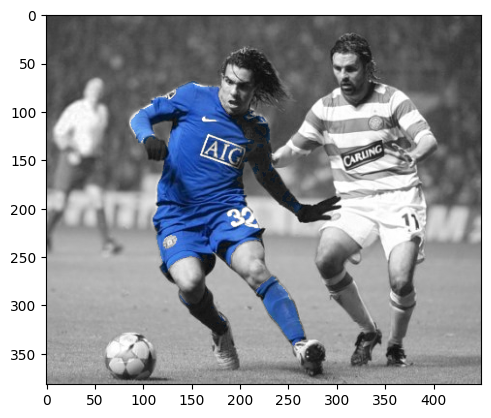

In [ ]:
h, s, v = cv2.split(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV))
#necesito el intervalo de H azul nomas

h_mean  = np.mean(np.ravel(h[150:200, 150:200]))
s_mean = np.mean(np.ravel(s[150:200, 150:200]))

h_std  = np.std(np.ravel(h[150:200, 150:200]))
s_std  = np.std(np.ravel(s[150:200, 150:200]))

# intervalo de confianza?
k = 2

roi_h = np.zeros_like(h)
roi_s = np.zeros_like(s)


def hiperplane(point):
    if h_mean - k*h_std<point[0]<h_mean + k*h_std and s_mean - k*s_std< point[1]<s_mean + k*s_std:
        return True
    return False

for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        point = np.array([
            h[i,j],
            s[i,j]]
        )
        if hiperplane(point) == True:
            roi_h[i,j] = h[i,j]
            roi_s[i,j] = s[i,j]


roi = cv2.merge([roi_h, roi_s, v])
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_HSV2RGB)

plt.imshow(roi_rgb)
plt.show()

#dou queda en gris








# ANALISIS DE PROFESORES!

In [ ]:
vector = ["s01i08HCM.png", "s03i10HDM.png", "s05i08HLB.png","s06i13HLV.png", "s08i06HMA.png"]

